# Notebook 4 — Entrenamiento de Modelo de IA

## Caso: Predicción de Default en Solicitudes de Préstamos

## Objetivo

Entrenar y evaluar un modelo de Machine Learning supervisado que permita predecir si una solicitud de préstamo tiene riesgo de incumplimiento (`loan_status` = 1) a partir de los datos ya limpios y validados por el pipeline (`loans_clean.csv`).

## Etapas

1. Cargar el dataset limpio y validado
2. Análisis de calidad de datos (estadísticas descriptivas, percentiles)
3. Análisis univariado de variables (distribución de la variable objetivo y variables numéricas)
4. Análisis bivariado y matriz de correlación
5. Preprocesamiento: codificación de variables categóricas
6. División en conjuntos de entrenamiento (80%) y prueba (20%)
7. Entrenamiento del modelo (Regresión Logística)
8. Evaluación con métricas: Accuracy, Precision, Recall, F1-Score, Matriz de Confusión, Curva ROC e Indicador Gini
9. Entrenamiento de un segundo modelo (Random Forest) para comparación
10. Conclusión y justificación del modelo elegido

## Paso 1: Importar Librerías

Se importan las librerías necesarias para el análisis exploratorio, preprocesamiento, entrenamiento y evaluación del modelo de Machine Learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## Paso 2: Cargar el Dataset

Se carga `loans_validos.csv`, el dataset final resultante del pipeline (Notebooks 1, 2 y 3), ya pasado por las etapas de ingesta, limpieza y validación.

In [3]:
df = pd.read_csv('../data/processed/loans_validos.csv')

print(f'✅ Dataset cargado correctamente')
print(f'   {df.shape[0]} solicitudes de préstamo  |  {df.shape[1]} variables')
print()
df.head(10)

✅ Dataset cargado correctamente
   44993 solicitudes de préstamo  |  14 variables



,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
5,21,female,High School,12951,0,OWN,2500,VENTURE,7.14,0.19,2,532,No,1
6,26,female,Bachelor,93471,1,RENT,35000,EDUCATION,12.42,0.37,3,701,No,1
7,24,female,High School,95550,5,RENT,35000,MEDICAL,11.11,0.37,4,585,No,1
8,24,female,Associate,100684,3,RENT,35000,PERSONAL,8.90,0.35,2,544,No,1
9,21,female,High School,12739,0,OWN,1600,VENTURE,14.74,0.13,3,640,No,1


## Paso 3: Análisis de Calidad de Datos

Verificamos la estructura general del dataset, la presencia de valores nulos y las estadísticas descriptivas (media, desviación estándar, percentiles) de las variables numéricas. Como el dataset ya fue procesado por las etapas de limpieza y validación del pipeline, se espera no encontrar valores nulos.

In [4]:
print('📋 Información general:')
print(df.info())
print()
print('🔎 Valores nulos por columna:')
print(df.isnull().sum())
print()
print('📊 Estadísticas descriptivas (variables numéricas):')
df.describe().round(2)

📋 Información general:
<class 'pandas.DataFrame'>
RangeIndex: 44993 entries, 0 to 44992
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  int64  
 1   person_gender                   44993 non-null  str    
 2   person_education                44993 non-null  str    
 3   person_income                   44993 non-null  int64  
 4   person_emp_exp                  44993 non-null  int64  
 5   person_home_ownership           44993 non-null  str    
 6   loan_amnt                       44993 non-null  int64  
 7   loan_intent                     44993 non-null  str    
 8   loan_int_rate                   44993 non-null  float64
 9   loan_percent_income             44993 non-null  float64
 10  cb_person_cred_hist_length      44993 non-null  int64  
 11  credit_score                    44993 non-null  int64  
 12  previous_loan_defaul

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00
mean,27.75,79908.45,5.39,9583.18,11.01,0.14,5.87,632.59,0.22
std,5.91,63322.13,5.93,6314.80,2.98,0.09,3.88,50.40,0.42
min,20.00,8000.00,0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,47195.00,1.00,5000.00,8.59,0.07,3.00,601.00,0.00
50%,26.00,67046.00,4.00,8000.00,11.01,0.12,4.00,640.00,0.00
75%,30.00,95778.00,8.00,12237.00,12.99,0.19,8.00,670.00,0.00
max,94.00,2448661.00,76.00,35000.00,20.00,0.66,30.00,784.00,1.00


## Paso 4: Análisis Univariado

Se examina la distribución de la variable objetivo (`loan_status`) y de las variables numéricas más relevantes del dataset, con el fin de comprender su comportamiento individual antes de avanzar al modelado.

🎯 Variable objetivo: loan_status
   Sin riesgo / paga (0): 34993 solicitudes (77.8%)
   En riesgo / default (1): 10000 solicitudes (22.2%)


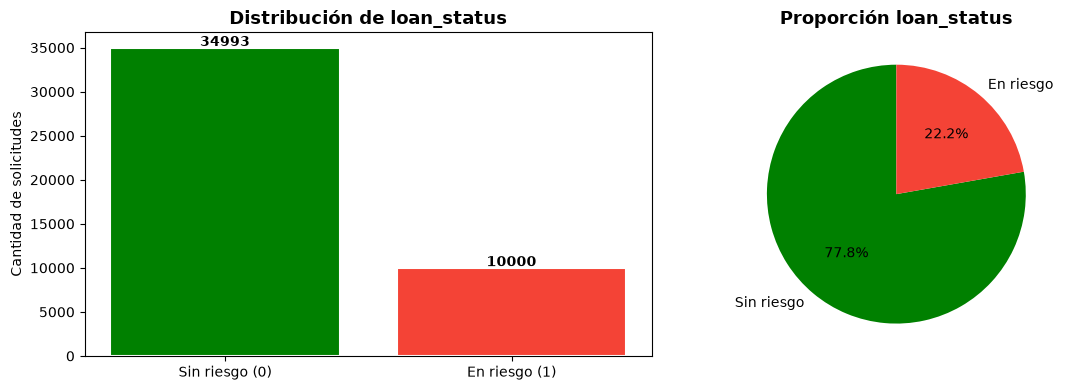

In [6]:
conteo = df['loan_status'].value_counts()
pct    = df['loan_status'].value_counts(normalize=True) * 100

print('🎯 Variable objetivo: loan_status')
print(f'   Sin riesgo / paga (0): {conteo[0]} solicitudes ({pct[0]:.1f}%)')
print(f'   En riesgo / default (1): {conteo[1]} solicitudes ({pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colores = ['green', '#F44336']
axes[0].bar(['Sin riesgo (0)', 'En riesgo (1)'], conteo.values,
            color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de loan_status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de solicitudes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['Sin riesgo', 'En riesgo'],
            autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporción loan_status', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Distribución de variables numéricas

Se analiza la distribución de las variables numéricas más relevantes: edad, ingreso anual, score crediticio y tasa de interés del préstamo.

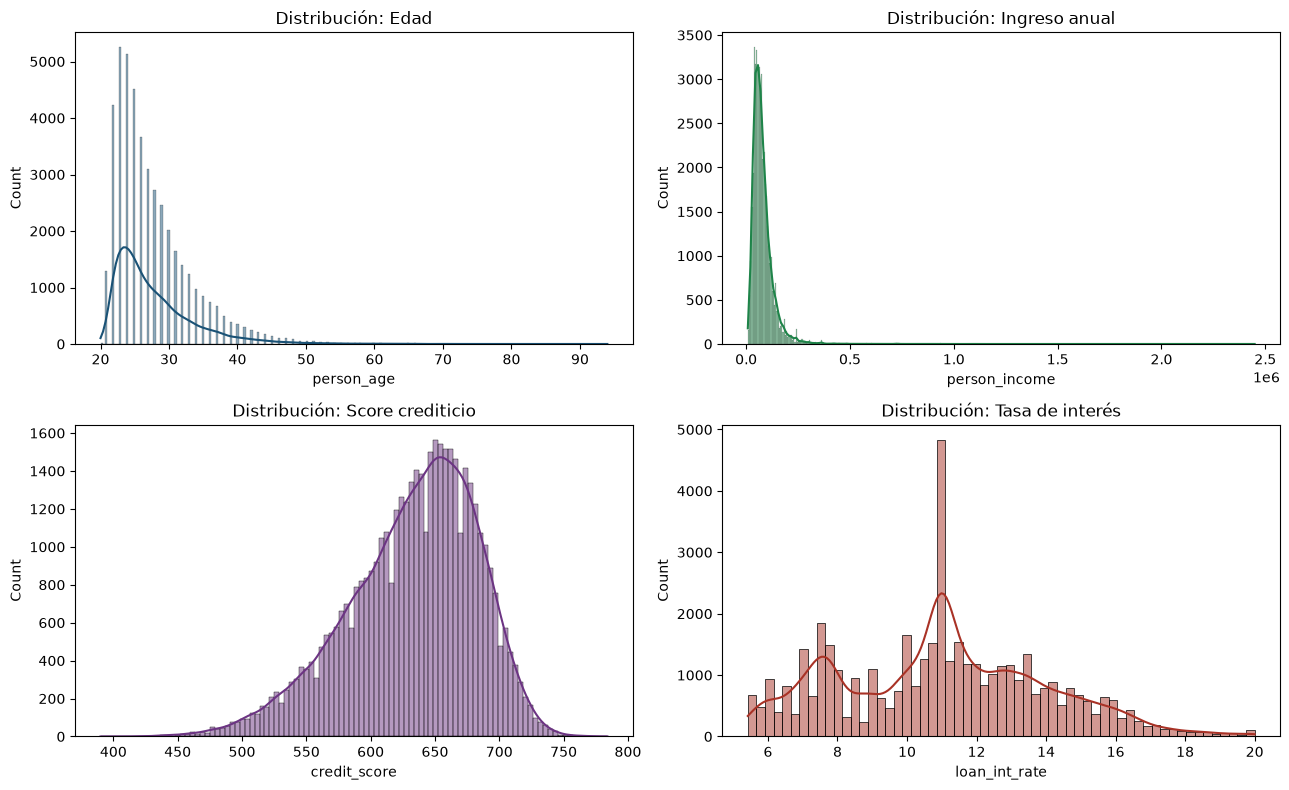

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(df['person_age'], kde=True, ax=axes[0,0], color='#1A5276')
axes[0,0].set_title('Distribución: Edad')

sns.histplot(df['person_income'], kde=True, ax=axes[0,1], color='#1E8449')
axes[0,1].set_title('Distribución: Ingreso anual')

sns.histplot(df['credit_score'], kde=True, ax=axes[1,0], color='#6C3483')
axes[1,0].set_title('Distribución: Score crediticio')

sns.histplot(df['loan_int_rate'], kde=True, ax=axes[1,1], color='#A93226')
axes[1,1].set_title('Distribución: Tasa de interés')

plt.tight_layout()
plt.show()